
# 🏠 House Price Prediction using Machine Learning

This project aims to predict house prices using machine learning regression algorithms.

The dataset contains information about different properties such as:
- Living area
- Number of bedrooms
- Number of bathrooms
- Number of floors
- Lot area
- Location-related features
- Other property characteristics

Multiple regression models are trained and evaluated to identify the model that provides the best prediction performance.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving House Price India.csv to House Price India.csv


## 📊 Dataset

The dataset contains 14,620 house records and 23 columns.

The target variable is **Price**, which represents the price of the house.

Before training the models, the dataset is checked for:
- Missing values
- Duplicate records
- Data types
- Statistical characteristics
- Feature relationships

In [3]:
df = pd.read_csv("House Price India.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (14620, 23)


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [6]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,...,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,6.762821e+09,42604.538646,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,...,1970.926402,90.924008,122033.062244,52.792848,-114.404007,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,6.237575e+03,67.347991,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,...,29.493625,416.216661,19.082418,0.137522,0.141326,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [7]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Target variable: Price")

print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Average Price:", df["Price"].mean())
print("Median Price:", df["Price"].median())

Target variable: Price
Minimum Price: 78000
Maximum Price: 7700000
Average Price: 538932.2183310534
Median Price: 450000.0


## 🔍 Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of house prices and the relationship between different features and the target variable.

The analysis includes:
- Price distribution
- Correlation analysis
- Feature-price relationships
- Important feature identification

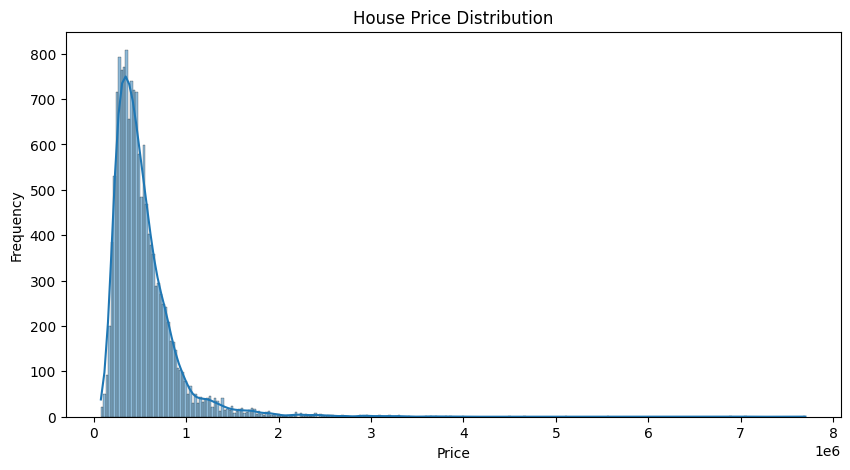

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Price"], kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [11]:
correlation = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)

print(correlation)

Price                                    1.000000
living area                              0.712169
grade of the house                       0.671814
Area of the house(excluding basement)    0.615220
living_area_renov                        0.584924
number of bathrooms                      0.531735
number of views                          0.395973
Area of the basement                     0.330202
number of bedrooms                       0.308460
Lattitude                                0.297490
waterfront present                       0.263687
number of floors                         0.262732
Renovation Year                          0.133173
lot area                                 0.081992
lot_area_renov                           0.075535
Built Year                               0.050307
condition of the house                   0.041376
Longitude                                0.024414
Number of schools nearby                 0.009890
Distance from the airport                0.003804


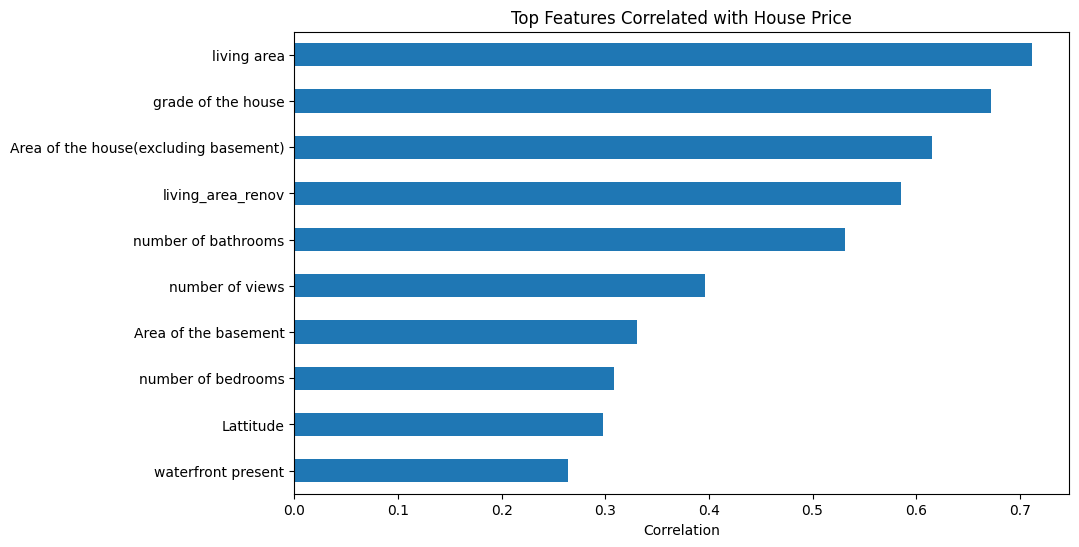

In [12]:
plt.figure(figsize=(10, 6))

correlation.drop("Price").head(10).sort_values().plot(kind="barh")

plt.title("Top Features Correlated with House Price")
plt.xlabel("Correlation")

plt.show()

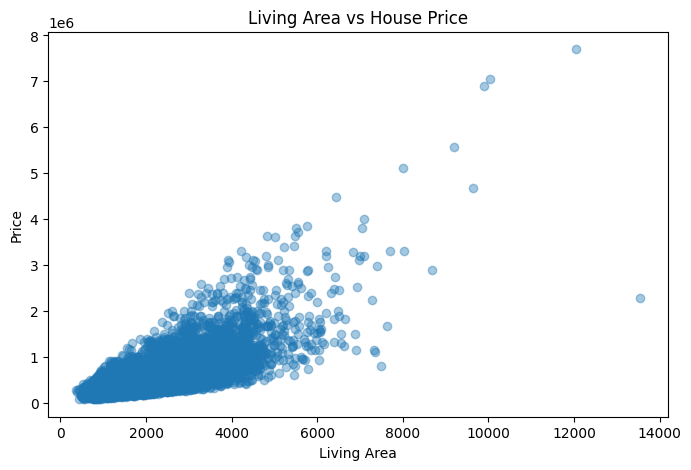

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["living area"], df["Price"], alpha=0.4)

plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("Living Area vs House Price")

plt.show()

## 🧹 Data Preprocessing

The `Price` column is used as the target variable.

The `id` column is removed because it is only an identifier and does not provide meaningful information for predicting house prices.

The remaining columns are used as input features.

The dataset is divided into:
- 80% training data
- 20% testing data

In [14]:
X = df.drop(columns=["Price", "id"])
y = df["Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (14620, 21)
Target shape: (14620,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11696, 21)
Testing data: (2924, 21)


## 🤖 Machine Learning Models

The following regression algorithms are trained and evaluated:

1. Linear Regression
2. Random Forest Regressor
3. Extra Trees Regressor
4. Gradient Boosting Regressor
5. HistGradientBoosting Regressor

The models are compared using standard regression evaluation metrics.

## 📈 Model Evaluation

The models are evaluated using three metrics:

### R² Score
Measures how well the model explains the variation in house prices. Higher values indicate better performance.

### MAE (Mean Absolute Error)
Measures the average absolute difference between actual and predicted prices. Lower values are better.

### RMSE (Root Mean Squared Error)
Measures prediction error while giving more weight to larger errors. Lower values are better.

In [16]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [17]:
linear_r2 = r2_score(y_test, linear_predictions)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

print("Linear Regression")
print("---------------------------")
print("R² Score :", linear_r2)
print("MAE      :", linear_mae)
print("RMSE     :", linear_rmse)

Linear Regression
---------------------------
R² Score : 0.7187664602478476
MAE      : 124782.64788149124
RMSE     : 199075.70223325028


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_features=0.8
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [20]:
rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest")
print("---------------------------")
print("R² Score :", rf_r2)
print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)

Random Forest
---------------------------
R² Score : 0.8745960880760678
MAE      : 69212.234748632
RMSE     : 132935.27611467405


In [24]:
from sklearn.ensemble import ExtraTreesRegressor

extra_model = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_features=1.0
)

extra_model.fit(X_train, y_train)

extra_predictions = extra_model.predict(X_test)

In [25]:
extra_r2 = r2_score(y_test, extra_predictions)
extra_mae = mean_absolute_error(y_test, extra_predictions)
extra_rmse = np.sqrt(mean_squared_error(y_test, extra_predictions))

print("Extra Trees Regressor")
print("---------------------------")
print("R² Score :", extra_r2)
print("MAE      :", extra_mae)
print("RMSE     :", extra_rmse)

Extra Trees Regressor
---------------------------
R² Score : 0.8805097579637802
MAE      : 68781.26528043776
RMSE     : 129763.01276752901


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

In [21]:
gb_r2 = r2_score(y_test, gb_predictions)
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

print("Gradient Boosting")
print("---------------------------")
print("R² Score :", gb_r2)
print("MAE      :", gb_mae)
print("RMSE     :", gb_rmse)

Gradient Boosting
---------------------------
R² Score : 0.8913752630670053
MAE      : 68066.64630897314
RMSE     : 123722.60872025981


In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hist_model.fit(X_train, y_train)

hist_predictions = hist_model.predict(X_test)

In [23]:
hist_r2 = r2_score(y_test, hist_predictions)
hist_mae = mean_absolute_error(y_test, hist_predictions)
hist_rmse = np.sqrt(mean_squared_error(y_test, hist_predictions))

print("HistGradientBoosting")
print("---------------------------")
print("R² Score :", hist_r2)
print("MAE      :", hist_mae)
print("RMSE     :", hist_rmse)

HistGradientBoosting
---------------------------
R² Score : 0.893349319423346
MAE      : 67289.55751922964
RMSE     : 122593.23781888344


## 🏆 Model Comparison

All trained models are compared using R² Score, MAE and RMSE.

The model with the highest R² Score is selected as the best-performing model, while MAE and RMSE are also considered to understand prediction error.

In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting"
    ],

    "R2 Score": [
        linear_r2,
        rf_r2,
        extra_r2,
        gb_r2,
        hist_r2
    ],

    "MAE": [
        linear_mae,
        rf_mae,
        extra_mae,
        gb_mae,
        hist_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse,
        extra_rmse,
        gb_rmse,
        hist_rmse
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results

,Model,R2 Score,MAE,RMSE
4,HistGradientBoosting,0.893349,67289.557519,122593.237819
3,Gradient Boosting,0.891375,68066.646309,123722.608720
2,Extra Trees,0.880510,68781.265280,129763.012768
1,Random Forest,0.874596,69212.234749,132935.276115
0,Linear Regression,0.718766,124782.647881,199075.702233


In [45]:
results.to_csv("model_comparison.csv", index=False)

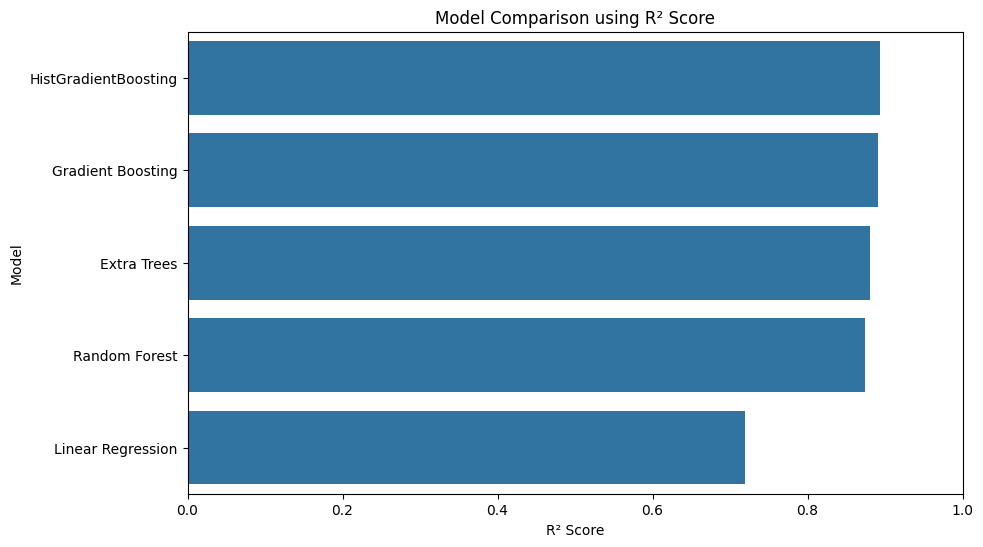

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="R2 Score",
    y="Model"
)

plt.title("Model Comparison using R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

In [28]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)
print("Best R² Score:", results.iloc[0]["R2 Score"])

Best Model: HistGradientBoosting
Best R² Score: 0.893349319423346


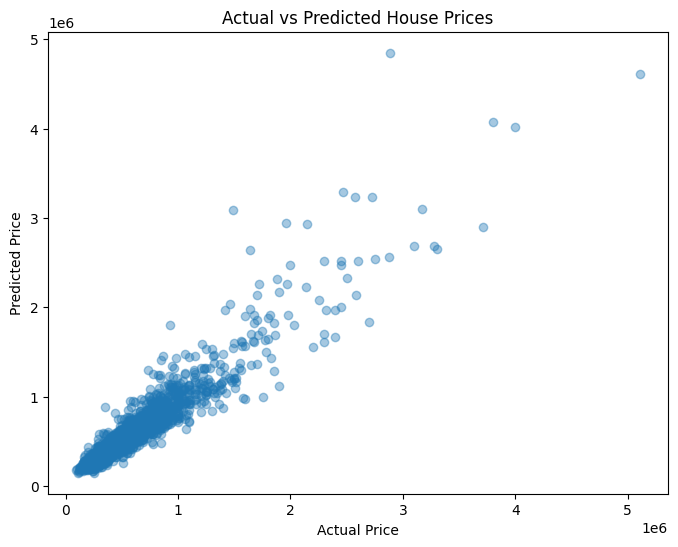

In [34]:
best_predictions = hist_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

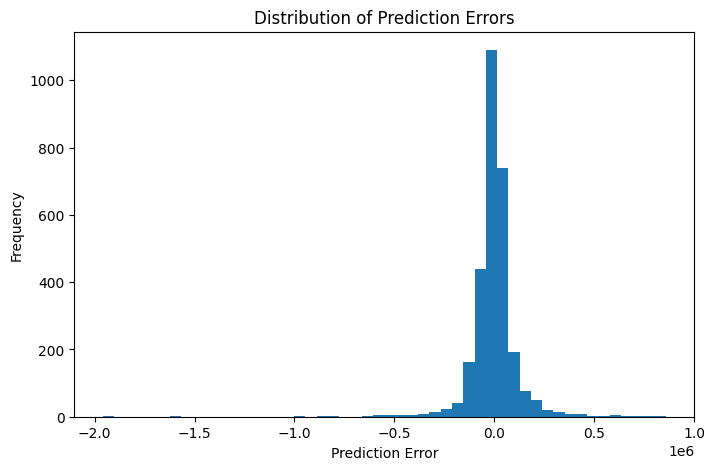

In [35]:
errors = y_test - best_predictions

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,living area,0.316305
9,grade of the house,0.288667
15,Lattitude,0.144958
16,Longitude,0.058873
6,waterfront present,0.035727
17,living_area_renov,0.030546
12,Built Year,0.029891
14,Postal Code,0.025322
10,Area of the house(excluding basement),0.024098
7,number of views,0.018381


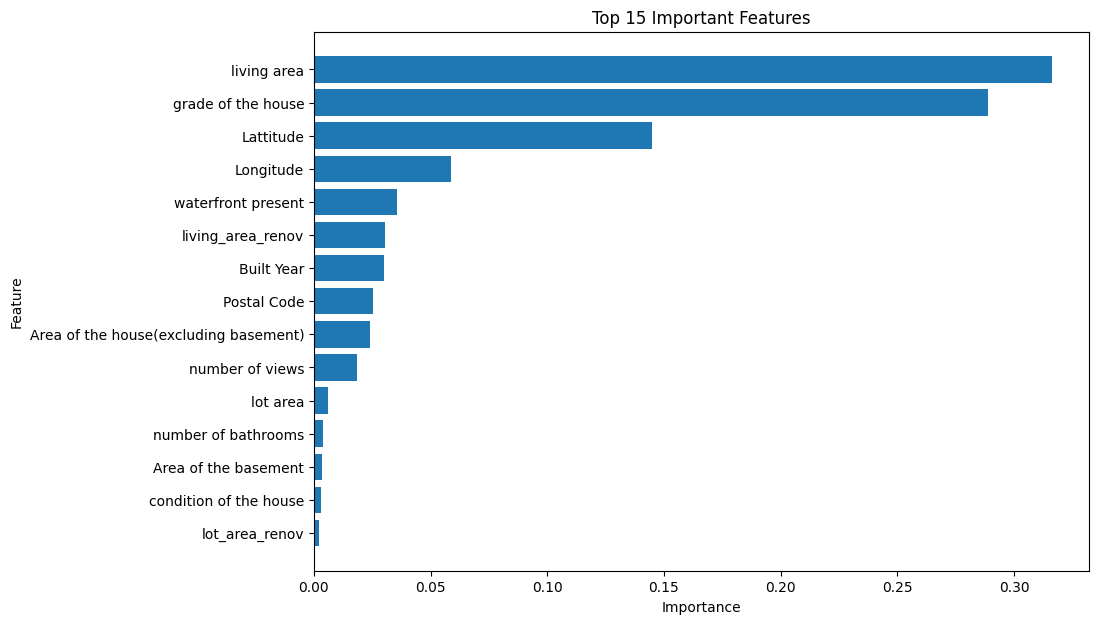

In [38]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")

plt.show()

In [39]:
sample_house = X.iloc[[0]]

predicted_price = hist_model.predict(sample_house)[0]

actual_price = y.iloc[0]

print("Actual Price    :", actual_price)
print("Predicted Price :", predicted_price)

Actual Price    : 2380000
Predicted Price : 2154722.207107313


In [30]:
import joblib

joblib.dump(hist_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [40]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [41]:
results.to_csv("model_comparison.csv", index=False)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [42]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>